# Toxic Chat Detection Using Machine Learning and Transformer Models

This notebook builds and evaluates a binary toxic / non-toxic text classifier for game-chat style text. It combines multiple text datasets, creates train/validation/unseen splits, compares classical machine-learning baselines, fine-tunes transformer models, performs overfitting analysis, evaluates the selected model on an unseen test set, and provides a Gradio demo interface.

> **Environment:** The notebook was developed in Google Colab. Dataset files are expected under `/content/` unless paths are changed.


# 1. Dataset Preparation

Load, normalize, label, balance, and merge the source datasets.

In [39]:
import pandas as pd

df1 = pd.read_csv("/content/CONDA_train.csv")

# Text
df1["text"] = df1["utterance"]

# Hybrid toxicity labeling
def make_label(row):

    intent = str(row["intentClass"])
    slots = str(row["slotClasses"])

    # Toxic intent
    if intent in ["E", "I", "A"]:
        return 1

    # Toxic token
    if "T" in slots.split():
        return 1

    return 0

df1["label"] = df1.apply(make_label, axis=1)

# Temizlik
df1 = df1[["text", "label"]]

df1 = df1.dropna()

df1 = df1.drop_duplicates(subset=["text"])

df1["label"] = df1["label"].astype(int)

print(df1.head())

print(df1["label"].value_counts())

      text  label
0     wow!      0
1      WTF      1
2  wpe wpe      0
3   hahaha      0
4      wtf      1
label
0    12451
1     6491
Name: count, dtype: int64


In [41]:
import pandas as pd

df2 = pd.read_csv("/content/CONDA_valid.csv")

# Text
df2["text"] = df2["utterance"]

# Hybrid toxicity labeling
def make_label(row):

    intent = str(row["intentClass"])
    slots = str(row["slotClasses"])

    # Toxic intent
    if intent in ["E", "I", "A"]:
        return 1

    # Toxic token
    if "T" in slots.split():
        return 1

    return 0

df2["label"] = df2.apply(make_label, axis=1)

# Temizlik
df2 = df2[["text", "label"]]

df2 = df2.dropna()

df2 = df2.drop_duplicates(subset=["text"])

df2["label"] = df2["label"].astype(int)

print(df2.head())

print(df2["label"].value_counts())

                       text  label
0                        GG      0
1                        gg      0
2  GG [SEPA] nice late game      0
3                       FUK      1
4                        ;)      0
label
0    4380
1    2288
Name: count, dtype: int64


In [43]:
import pandas as pd

# Jigsaw dataseti oku
df3 = pd.read_csv("/content/train.csv")

# Text
df3["text"] = df3["comment_text"]

# Toxic kolonları
toxic_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

# Binary label
df3["label"] = df3[toxic_columns].max(axis=1)

# Sadece gerekli kolonlar
df3 = df3[["text", "label"]]

# Temizlik
df3 = df3.dropna()

df3 = df3.drop_duplicates(subset=["text"])

# Toxic / Non-toxic ayır
toxic_df = df3[df3["label"] == 1]

non_toxic_df = df3[df3["label"] == 0]

# 10K sample al
toxic_sample = toxic_df.sample(
    n=12000,
    random_state=42
)

non_toxic_sample = non_toxic_df.sample(
    n=12000,
    random_state=42
)

# Birleştir
balanced_jigsaw = pd.concat([
    toxic_sample,
    non_toxic_sample
])

# Karıştır
balanced_jigsaw = balanced_jigsaw.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Kaydet
balanced_jigsaw.to_csv(
    "balanced_jigsaw_20k.csv",
    index=False,
    encoding="utf-8-sig"
)

df3 = balanced_jigsaw

print(balanced_jigsaw["label"].value_counts())

print(balanced_jigsaw.shape)

label
1    12000
0    12000
Name: count, dtype: int64
(24000, 2)


In [44]:
df4 = pd.read_csv("/content/english_gaming_sarcasm_toxic_dataset_10000.csv")
df4.shape

(10000, 2)

In [45]:
df5 = pd.read_csv("/content/english_gaming_family_sarcasm_contrast_5000.csv")
df5.columns

Index(['text', 'label'], dtype='object')

In [46]:
import pandas as pd

# Datasetler
# df1
# df2
# df3
# df4
# df5

# Birleştir
final_df = pd.concat(
    [df1, df2, df3, df4, df5],
    ignore_index=True
)

# Karıştır
final_df = final_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Duplicate temizle
final_df = final_df.drop_duplicates(
    subset=["text"]
)

# Boşları temizle
final_df = final_df.dropna(
    subset=["text", "label"]
)

# Label tipi
final_df["label"] = final_df["label"].astype(int)

# Kontrol
print(final_df.shape)

print(final_df["label"].value_counts())

print(final_df.head())

# Kaydet
final_df.to_csv(
    "/content/final_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

final_df.to_excel(
    "/content/final_dataset.xlsx",
    index=False
)

print("Final dataset hazır.")

(62880, 2)
label
0    34799
1    28081
Name: count, dtype: int64
                                                text  label
0                                                 >>      0
1                                            me too]      0
2                                           wr invis      0
3  Amazing clutch, my hands were only shaking a l...      0
4  DiD you blocked me ? I warned not to do it . Y...      1
Final dataset hazır.


In [9]:
import pandas as pd

df = pd.read_csv("/content/final_dataset.csv")

df = df.dropna(subset=["text", "label"])
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)
df = df.drop_duplicates(subset=["text"])

print(df.shape)
print(df["label"].value_counts())
print(df.head())

(62880, 2)
label
0    34799
1    28081
Name: count, dtype: int64
                                                text  label
0                                                 >>      0
1                                            me too]      0
2                                           wr invis      0
3  Amazing clutch, my hands were only shaking a l...      0
4  DiD you blocked me ? I warned not to do it . Y...      1


In [ ]:
!pip install evaluate -q

# 2. Train / Validation / Unseen Split

Create stratified splits for model development and final evaluation.

In [11]:
from sklearn.model_selection import train_test_split

# %5 unseen test
train_val_df, unseen_df = train_test_split(
    df,
    test_size=0.05,
    random_state=42,
    stratify=df["label"]
)

# Kalan veriyi train / validation
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    random_state=42,
    stratify=train_val_df["label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Unseen:", unseen_df.shape)

print("\nTrain dağılımı:")
print(train_df["label"].value_counts())

print("\nValidation dağılımı:")
print(val_df["label"].value_counts())

print("\nUnseen dağılımı:")
print(unseen_df["label"].value_counts())

Train: (47788, 2)
Validation: (11948, 2)
Unseen: (3144, 2)

Train dağılımı:
label
0    26447
1    21341
Name: count, dtype: int64

Validation dağılımı:
label
0    6612
1    5336
Name: count, dtype: int64

Unseen dağılımı:
label
0    1740
1    1404
Name: count, dtype: int64


In [12]:
train_df.to_csv(
    "/content/train_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

val_df.to_csv(
    "/content/validation_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

unseen_df.to_csv(
    "/content/unseen_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Kaydedildi.")

Kaydedildi.


# 3. Classical Machine Learning Baselines

Evaluate TF-IDF with Logistic Regression and Linear SVM.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================
# LOGISTIC REGRESSION BASE
# =========================

# TF-IDF
vectorizer_lr = TfidfVectorizer(
    max_features=20000
)

X_train_lr = vectorizer_lr.fit_transform(train_df["text"])
X_val_lr = vectorizer_lr.transform(val_df["text"])

y_train = train_df["label"]
y_val = val_df["label"]

# Model
lr_base_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Eğitim
lr_base_model.fit(X_train_lr, y_train)

# Tahmin
lr_pred = lr_base_model.predict(X_val_lr)

# Metrikler
lr_acc = accuracy_score(y_val, lr_pred)
lr_precision = precision_score(y_val, lr_pred)
lr_recall = recall_score(y_val, lr_pred)
lr_f1 = f1_score(y_val, lr_pred)

# Sonuçlar
print("===== Logistic Regression BASE Results =====")
print("Accuracy :", lr_acc)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, lr_pred))

print("\nClassification Report:")
print(classification_report(y_val, lr_pred))

# Sonuçları listeye ekle
results = []

results.append({
    "Model": "Logistic Regression Base",
    "Accuracy": lr_acc,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1": lr_f1
})

results_df = pd.DataFrame(results)
results_df

===== Logistic Regression BASE Results =====
Accuracy : 0.9056745898895212
Precision: 0.933649289099526
Recall   : 0.8491379310344828
F1 Score : 0.8893905191873589

Confusion Matrix:
[[6290  322]
 [ 805 4531]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      6612
           1       0.93      0.85      0.89      5336

    accuracy                           0.91     11948
   macro avg       0.91      0.90      0.90     11948
weighted avg       0.91      0.91      0.91     11948



,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression Base,0.905675,0.933649,0.849138,0.889391


In [14]:
from sklearn.metrics import accuracy_score, f1_score

train_pred = lr_base_model.predict(X_train_lr)

train_acc = accuracy_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred)

print("Train Accuracy:", train_acc)
print("Train F1:", train_f1)

print("Validation Accuracy:", lr_acc)
print("Validation F1:", lr_f1)

Train Accuracy: 0.9212982338662425
Train F1: 0.9075580680840605
Validation Accuracy: 0.9056745898895212
Validation F1: 0.8893905191873589


ROC AUC: 0.9642314165059032


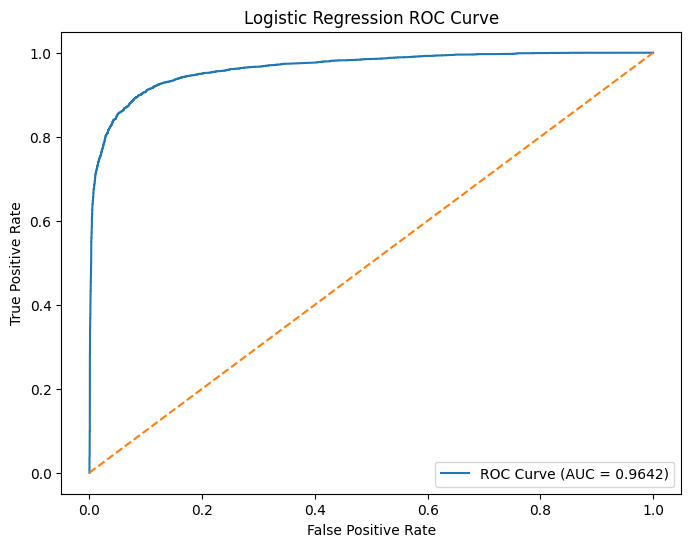

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Toxic olma olasılığı
y_scores = lr_base_model.predict_proba(X_val_lr)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_val, y_scores)

roc_auc = auc(fpr, tpr)

print("ROC AUC:", roc_auc)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()

plt.show()

Average Precision: 0.9615235439675971


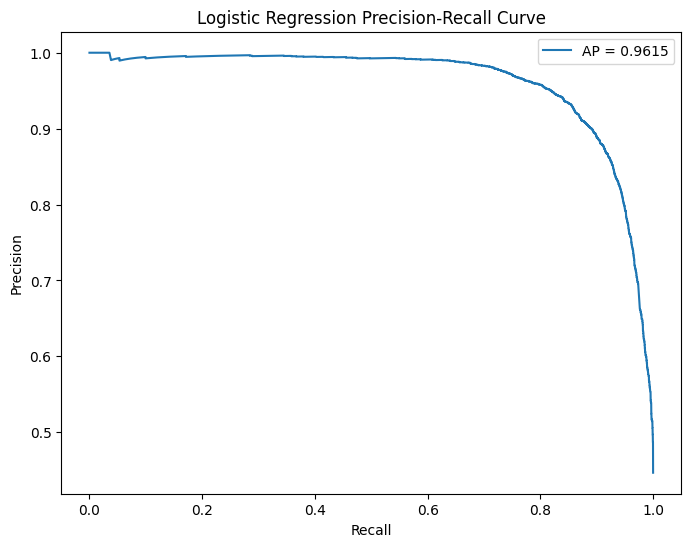

In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_scores = lr_base_model.predict_proba(X_val_lr)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
ap_score = average_precision_score(y_val, y_scores)

print("Average Precision:", ap_score)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression Precision-Recall Curve")
plt.legend()
plt.show()

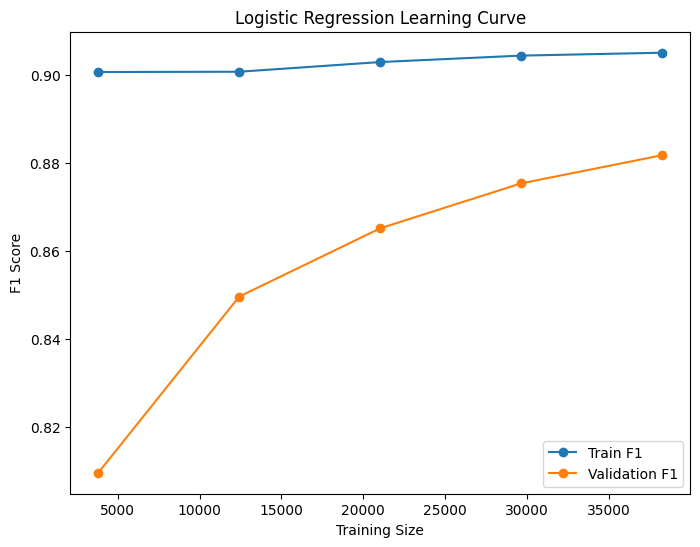

In [17]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    lr_base_model,
    X_train_lr,
    y_train,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, marker="o", label="Train F1")
plt.plot(train_sizes, val_mean, marker="o", label="Validation F1")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Logistic Regression Learning Curve")
plt.legend()
plt.show()

In [18]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================
# LINEAR SVM BASE
# =========================

svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

# eğitim
svm_model.fit(
    X_train_lr,
    y_train
)

# tahmin
svm_pred = svm_model.predict(
    X_val_lr
)

# metrikler
svm_acc = accuracy_score(
    y_val,
    svm_pred
)

svm_precision = precision_score(
    y_val,
    svm_pred
)

svm_recall = recall_score(
    y_val,
    svm_pred
)

svm_f1 = f1_score(
    y_val,
    svm_pred
)

print("===== Linear SVM BASE =====")

print("Accuracy :", svm_acc)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

print("\nConfusion Matrix")
print(confusion_matrix(y_val, svm_pred))

print("\nClassification Report")
print(classification_report(y_val, svm_pred))

===== Linear SVM BASE =====
Accuracy : 0.9189822564445932
Precision: 0.9361022364217252
Recall   : 0.8785607196401799
F1 Score : 0.9064191802010828

Confusion Matrix
[[6292  320]
 [ 648 4688]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      6612
           1       0.94      0.88      0.91      5336

    accuracy                           0.92     11948
   macro avg       0.92      0.92      0.92     11948
weighted avg       0.92      0.92      0.92     11948



In [19]:
train_pred = svm_model.predict(
    X_train_lr
)

train_acc = accuracy_score(
    y_train,
    train_pred
)

train_f1 = f1_score(
    y_train,
    train_pred
)

print("Train Accuracy:", train_acc)
print("Train F1:", train_f1)

print("Validation Accuracy:", svm_acc)
print("Validation F1:", svm_f1)

Train Accuracy: 0.9608897631204486
Train F1: 0.9552945678953285
Validation Accuracy: 0.9189822564445932
Validation F1: 0.9064191802010828


===== Linear SVM BASE Results =====
Accuracy : 0.9189822564445932
Precision: 0.9361022364217252
Recall   : 0.8785607196401799
F1 Score : 0.9064191802010828

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      6612
           1       0.94      0.88      0.91      5336

    accuracy                           0.92     11948
   macro avg       0.92      0.92      0.92     11948
weighted avg       0.92      0.92      0.92     11948


===== Overfitting Analysis =====
Train Accuracy: 0.9608897631204486
Validation Accuracy: 0.9189822564445932
Train F1: 0.9552945678953285
Validation F1: 0.9064191802010828


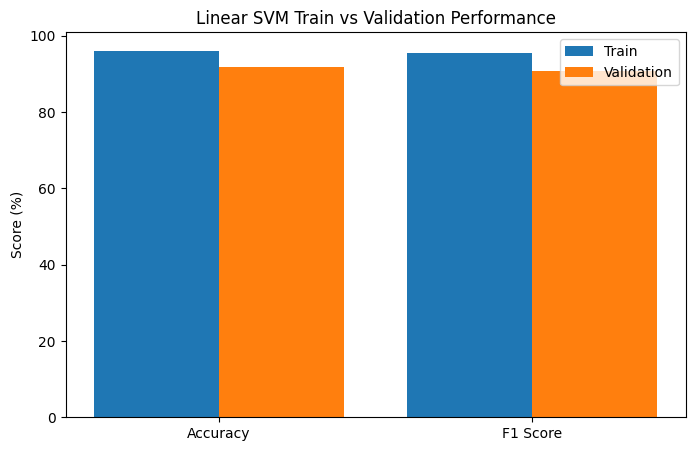

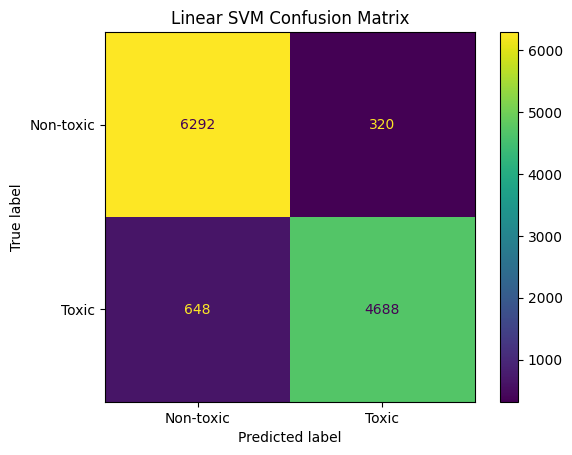


ROC AUC: 0.9678827782116202


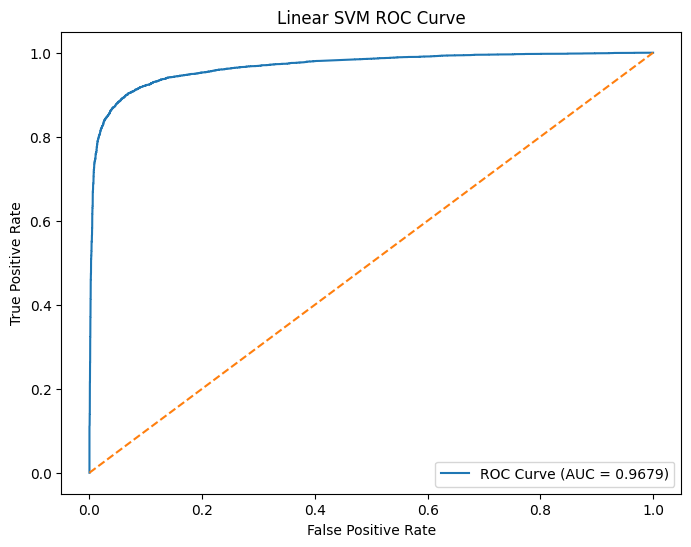

Average Precision: 0.966626904251529


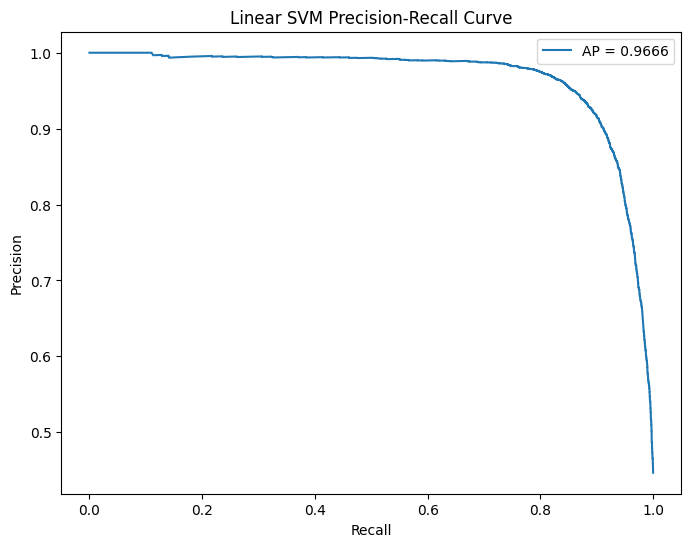

In [20]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt

# =========================
# LINEAR SVM BASE
# =========================

svm_base_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_base_model.fit(X_train_lr, y_train)

# Validation prediction
svm_val_pred = svm_base_model.predict(X_val_lr)

svm_acc = accuracy_score(y_val, svm_val_pred)
svm_precision = precision_score(y_val, svm_val_pred)
svm_recall = recall_score(y_val, svm_val_pred)
svm_f1 = f1_score(y_val, svm_val_pred)

print("===== Linear SVM BASE Results =====")
print("Accuracy :", svm_acc)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

print("\nClassification Report:")
print(classification_report(y_val, svm_val_pred))

# =========================
# TRAIN vs VALIDATION GAP
# =========================

svm_train_pred = svm_base_model.predict(X_train_lr)

svm_train_acc = accuracy_score(y_train, svm_train_pred)
svm_train_f1 = f1_score(y_train, svm_train_pred)

print("\n===== Overfitting Analysis =====")
print("Train Accuracy:", svm_train_acc)
print("Validation Accuracy:", svm_acc)
print("Train F1:", svm_train_f1)
print("Validation F1:", svm_f1)

# Bar chart
metrics = ["Accuracy", "F1 Score"]
train_scores = [svm_train_acc * 100, svm_train_f1 * 100]
val_scores = [svm_acc * 100, svm_f1 * 100]

x = range(len(metrics))

plt.figure(figsize=(8, 5))
plt.bar([i - 0.2 for i in x], train_scores, width=0.4, label="Train")
plt.bar([i + 0.2 for i in x], val_scores, width=0.4, label="Validation")
plt.xticks(x, metrics)
plt.ylabel("Score (%)")
plt.title("Linear SVM Train vs Validation Performance")
plt.legend()
plt.show()

# =========================
# CONFUSION MATRIX
# =========================

ConfusionMatrixDisplay.from_predictions(
    y_val,
    svm_val_pred,
    display_labels=["Non-toxic", "Toxic"]
)

plt.title("Linear SVM Confusion Matrix")
plt.show()

# =========================
# ROC CURVE
# LinearSVC predict_proba vermez.
# Bu yüzden decision_function kullanıyoruz.
# =========================

svm_scores = svm_base_model.decision_function(X_val_lr)

fpr, tpr, thresholds = roc_curve(y_val, svm_scores)
roc_auc = auc(fpr, tpr)

print("\nROC AUC:", roc_auc)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Linear SVM ROC Curve")
plt.legend()
plt.show()

# =========================
# PRECISION-RECALL CURVE
# =========================

precision, recall, thresholds = precision_recall_curve(y_val, svm_scores)
ap_score = average_precision_score(y_val, svm_scores)

print("Average Precision:", ap_score)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Linear SVM Precision-Recall Curve")
plt.legend()
plt.show()

# 4. Transformer Models

Fine-tune DistilRoBERTa and RoBERTa sequence-classification models.

In [ ]:
!pip uninstall -y pyarrow datasets evaluate
!pip install -U --no-cache-dir pyarrow datasets evaluate

In [ ]:
# =========================
# FIX TORCHVISION ERROR
# =========================
!pip uninstall torchvision -y
!pip install -U transformers datasets evaluate accelerate scikit-learn -q

import sys

if "torchvision" in sys.modules:
    del sys.modules["torchvision"]

# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import torch
import evaluate

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# =========================
# DATASET
# train_df ve val_df daha önce oluşturulmuş olmalı
# kolonlar: text, label
# =========================

train_df = train_df.dropna(subset=["text", "label"]).copy()
val_df = val_df.dropna(subset=["text", "label"]).copy()

train_df["text"] = train_df["text"].astype(str)
val_df["text"] = val_df["text"].astype(str)

train_df["label"] = train_df["label"].astype(int)
val_df["label"] = val_df["label"].astype(int)

# HuggingFace dataset
train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]].reset_index(drop=True)
)

val_dataset = Dataset.from_pandas(
    val_df[["text", "label"]].reset_index(drop=True)
)

# =========================
# MODEL / TOKENIZER
# =========================

model_name = "distilroberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=64
    )

train_dataset = train_dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)

train_dataset = train_dataset.rename_column(
    "label",
    "labels"
)

val_dataset = val_dataset.rename_column(
    "label",
    "labels"
)

# Önemli: set_format("torch") kullanmıyoruz.
# Torchvision VideoReader hatasını bu şekilde bypass ediyoruz.

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

# =========================
# MODEL
# =========================

distil_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

device = "cuda" if torch.cuda.is_available() else "cpu"

distil_model.to(device)

print("Kullanılan cihaz:", device)

# =========================
# METRICS
# =========================

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels
    )["f1"]

    return {
        "accuracy": accuracy,
        "f1": f1
    }

# =========================
# TRAINING ARGUMENTS - BASE
# =========================

training_args = TrainingArguments(
    output_dir="/content/distilroberta_base_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=False,
    report_to="none"
)

# =========================
# TRAINER
# =========================

distil_trainer = Trainer(
    model=distil_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# =========================
# TRAIN
# =========================

distil_trainer.train()

# =========================
# EVALUATE
# =========================

distil_results = distil_trainer.evaluate()

print("===== DistilRoBERTa BASE Results =====")
print(distil_results)

# =========================
# SAVE
# =========================

distil_trainer.save_model(
    "/content/final_distilroberta_base_model"
)

tokenizer.save_pretrained(
    "/content/final_distilroberta_base_model"
)

print("DistilRoBERTa base model kaydedildi.")

In [ ]:
# =========================
# RoBERTa BASE MODEL
# =========================

!pip install -U transformers datasets evaluate accelerate scikit-learn -q

import pandas as pd
import numpy as np
import torch
import evaluate

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# =========================
# DATASET
# train_df ve val_df hazır olmalı
# kolonlar: text, label
# =========================

train_clean = train_df[["text", "label"]].dropna().copy()
val_clean = val_df[["text", "label"]].dropna().copy()

train_clean["text"] = train_clean["text"].astype(str)
val_clean["text"] = val_clean["text"].astype(str)

train_clean["label"] = train_clean["label"].astype(int)
val_clean["label"] = val_clean["label"].astype(int)

train_dataset = Dataset.from_pandas(
    train_clean.reset_index(drop=True)
)

val_dataset = Dataset.from_pandas(
    val_clean.reset_index(drop=True)
)

# =========================
# MODEL / TOKENIZER
# =========================

model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=64
    )

train_dataset = train_dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)

train_dataset = train_dataset.rename_column(
    "label",
    "labels"
)

val_dataset = val_dataset.rename_column(
    "label",
    "labels"
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

# =========================
# MODEL
# =========================

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

device = "cuda" if torch.cuda.is_available() else "cpu"

roberta_model.to(device)

print("Kullanılan cihaz:", device)

# =========================
# METRICS
# =========================

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels
    )["f1"]

    return {
        "accuracy": accuracy,
        "f1": f1
    }

# =========================
# TRAINING ARGUMENTS - BASE
# =========================

training_args = TrainingArguments(
    output_dir="/content/roberta_base_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=False,
    report_to="none"
)

# =========================
# TRAINER
# =========================

roberta_trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# =========================
# TRAIN
# =========================

roberta_trainer.train()

# =========================
# EVALUATE
# =========================

roberta_results = roberta_trainer.evaluate()

print("===== RoBERTa BASE Results =====")
print(roberta_results)

# =========================
# SAVE
# =========================

roberta_trainer.save_model(
    "/content/final_roberta_base_model"
)

tokenizer.save_pretrained(
    "/content/final_roberta_base_model"
)

print("RoBERTa base model kaydedildi.")

In [24]:
#Burdan sonrası hiperparametreler

# 5. Hyperparameter Tuning

Tune classical models and transformer training settings.

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

lr_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"],
    "max_iter": [1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_lr, y_train)

best_lr_model = lr_grid.best_estimator_

lr_tuned_pred = best_lr_model.predict(X_val_lr)

lr_tuned_acc = accuracy_score(y_val, lr_tuned_pred)
lr_tuned_precision = precision_score(y_val, lr_tuned_pred)
lr_tuned_recall = recall_score(y_val, lr_tuned_pred)
lr_tuned_f1 = f1_score(y_val, lr_tuned_pred)

print("===== Logistic Regression Tuned =====")
print("Best Params:", lr_grid.best_params_)
print("Accuracy :", lr_tuned_acc)
print("Precision:", lr_tuned_precision)
print("Recall   :", lr_tuned_recall)
print("F1 Score :", lr_tuned_f1)
print(classification_report(y_val, lr_tuned_pred))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
===== Logistic Regression Tuned =====
Best Params: {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
Accuracy : 0.9168061600267827
Precision: 0.934721665999199
Recall   : 0.8748125937031485
F1 Score : 0.9037754114230397
              precision    recall  f1-score   support

           0       0.90      0.95      0.93      6612
           1       0.93      0.87      0.90      5336

    accuracy                           0.92     11948
   macro avg       0.92      0.91      0.92     11948
weighted avg       0.92      0.92      0.92     11948



In [26]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

svm_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "loss": ["squared_hinge"],
    "max_iter": [3000]
}

svm_grid = GridSearchCV(
    LinearSVC(random_state=42),
    svm_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_lr, y_train)

best_svm_model = svm_grid.best_estimator_

svm_tuned_pred = best_svm_model.predict(X_val_lr)

svm_tuned_acc = accuracy_score(y_val, svm_tuned_pred)
svm_tuned_precision = precision_score(y_val, svm_tuned_pred)
svm_tuned_recall = recall_score(y_val, svm_tuned_pred)
svm_tuned_f1 = f1_score(y_val, svm_tuned_pred)

print("===== Linear SVM Tuned =====")
print("Best Params:", svm_grid.best_params_)
print("Accuracy :", svm_tuned_acc)
print("Precision:", svm_tuned_precision)
print("Recall   :", svm_tuned_recall)
print("F1 Score :", svm_tuned_f1)
print(classification_report(y_val, svm_tuned_pred))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
===== Linear SVM Tuned =====
Best Params: {'C': 1, 'loss': 'squared_hinge', 'max_iter': 3000}
Accuracy : 0.9189822564445932
Precision: 0.9361022364217252
Recall   : 0.8785607196401799
F1 Score : 0.9064191802010828
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      6612
           1       0.94      0.88      0.91      5336

    accuracy                           0.92     11948
   macro avg       0.92      0.92      0.92     11948
weighted avg       0.92      0.92      0.92     11948



In [ ]:
# =========================
# DISTILROBERTA TUNED MODEL + EARLY STOPPING
# =========================

!pip install -U transformers datasets evaluate accelerate scikit-learn -q

import pandas as pd
import numpy as np
import torch
import evaluate

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

# =========================
# DATASET
# =========================

train_clean = train_df[["text", "label"]].dropna().copy()
val_clean = val_df[["text", "label"]].dropna().copy()

train_clean["text"] = train_clean["text"].astype(str)
val_clean["text"] = val_clean["text"].astype(str)

train_clean["label"] = train_clean["label"].astype(int)
val_clean["label"] = val_clean["label"].astype(int)

train_dataset = Dataset.from_pandas(train_clean.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_clean.reset_index(drop=True))

# =========================
# MODEL / TOKENIZER
# =========================

model_name = "distilroberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# =========================
# MODEL
# =========================

distil_tuned_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

device = "cuda" if torch.cuda.is_available() else "cpu"
distil_tuned_model.to(device)

print("Kullanılan cihaz:", device)

# =========================
# METRICS
# =========================

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels
    )["f1"]

    return {
        "accuracy": accuracy,
        "f1": f1
    }

# =========================
# TRAINING ARGUMENTS - TUNED + EARLY STOPPING
# =========================

training_args = TrainingArguments(
    output_dir="/content/distilroberta_tuned_early_stopping",

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    learning_rate=1e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    # Early stopping için validation loss izliyoruz
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=False,
    report_to="none",

    save_total_limit=2
)

# =========================
# TRAINER
# =========================

distil_tuned_trainer = Trainer(
    model=distil_tuned_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

# =========================
# TRAIN
# =========================

distil_tuned_trainer.train()

# =========================
# EVALUATE
# =========================

distil_tuned_results = distil_tuned_trainer.evaluate()

print("===== DistilRoBERTa TUNED + EARLY STOPPING Results =====")
print(distil_tuned_results)

# =========================
# LOG HISTORY
# =========================

print("===== Training History =====")
for log in distil_tuned_trainer.state.log_history:
    print(log)

# =========================
# BEST EPOCH INFO
# =========================

best_checkpoint = distil_tuned_trainer.state.best_model_checkpoint
best_metric = distil_tuned_trainer.state.best_metric

print("\n===== Best Model Info =====")
print("Best checkpoint:", best_checkpoint)
print("Best eval_loss:", best_metric)

# checkpoint-xxxx içinden epoch tahmini
steps_per_epoch = len(train_dataset) / training_args.per_device_train_batch_size

if best_checkpoint is not None:
    checkpoint_step = int(best_checkpoint.split("-")[-1])
    best_epoch = checkpoint_step / steps_per_epoch

    print("Best epoch approximately:", round(best_epoch, 2))

# =========================
# SAVE MODEL
# =========================

distil_tuned_trainer.save_model(
    "/content/final_distilroberta_tuned_early_stopping_model"
)

tokenizer.save_pretrained(
    "/content/final_distilroberta_tuned_early_stopping_model"
)

print("DistilRoBERTa tuned + early stopping model kaydedildi.")

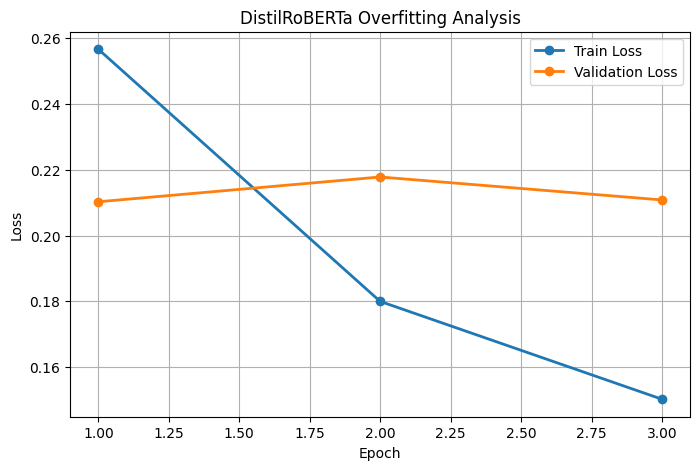

In [28]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]

train_loss = [
    0.256618,
    0.179991,
    0.150264
]

val_loss = [
    0.210264,
    0.217796,
    0.210819
]

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    linewidth=2,
    label="Train Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilRoBERTa Overfitting Analysis")
plt.legend()
plt.grid(True)

plt.savefig(
    "distilroberta_overfitting.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# =========================
# ROBERTA TUNED + EARLY STOPPING
# =========================

!pip install -U transformers datasets evaluate accelerate scikit-learn -q

import pandas as pd
import numpy as np
import torch
import evaluate

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

# =========================
# DATASET
# =========================

train_clean = train_df[["text", "label"]].dropna().copy()
val_clean = val_df[["text", "label"]].dropna().copy()

train_clean["text"] = train_clean["text"].astype(str)
val_clean["text"] = val_clean["text"].astype(str)

train_clean["label"] = train_clean["label"].astype(int)
val_clean["label"] = val_clean["label"].astype(int)

train_dataset = Dataset.from_pandas(train_clean.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_clean.reset_index(drop=True))

# =========================
# MODEL / TOKENIZER
# =========================

model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# =========================
# MODEL
# =========================

roberta_tuned_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

device = "cuda" if torch.cuda.is_available() else "cpu"
roberta_tuned_model.to(device)

print("Kullanılan cihaz:", device)

# =========================
# METRICS
# =========================

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels
    )["f1"]

    return {
        "accuracy": accuracy,
        "f1": f1
    }

# =========================
# TRAINING ARGUMENTS - TUNED + EARLY STOPPING
# =========================

training_args = TrainingArguments(
    output_dir="/content/roberta_tuned_early_stopping",

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    learning_rate=1e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=False,
    report_to="none",

    save_total_limit=2
)

# =========================
# TRAINER
# =========================

roberta_tuned_trainer = Trainer(
    model=roberta_tuned_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

# =========================
# TRAIN
# =========================

roberta_tuned_trainer.train()

# =========================
# EVALUATE
# =========================

roberta_tuned_results = roberta_tuned_trainer.evaluate()

print("===== RoBERTa TUNED + EARLY STOPPING Results =====")
print(roberta_tuned_results)

# =========================
# LOG HISTORY
# =========================

print("===== Training History =====")
for log in roberta_tuned_trainer.state.log_history:
    print(log)

# =========================
# BEST MODEL INFO
# =========================

best_checkpoint = roberta_tuned_trainer.state.best_model_checkpoint
best_metric = roberta_tuned_trainer.state.best_metric

print("\n===== Best Model Info =====")
print("Best checkpoint:", best_checkpoint)
print("Best eval_loss:", best_metric)

steps_per_epoch = len(train_dataset) / training_args.per_device_train_batch_size

if best_checkpoint is not None:
    checkpoint_step = int(best_checkpoint.split("-")[-1])
    best_epoch = checkpoint_step / steps_per_epoch
    print("Best epoch approximately:", round(best_epoch, 2))

# =========================
# SAVE MODEL
# =========================

roberta_tuned_trainer.save_model(
    "/content/final_roberta_tuned_early_stopping_model"
)

tokenizer.save_pretrained(
    "/content/final_roberta_tuned_early_stopping_model"
)

print("RoBERTa tuned + early stopping model kaydedildi.")

   epoch  train_loss  validation_loss  generalization_gap  \
0    1.0    0.250632         0.205305           -0.045327   
1    2.0    0.173807         0.202479            0.028672   
2    3.0    0.143535         0.244401            0.100866   
3    4.0    0.118226         0.277799            0.159573   

   validation_accuracy  validation_f1  
0             0.929109       0.922627  
1             0.944844       0.937660  
2             0.938483       0.932026  
3             0.943254       0.936242  


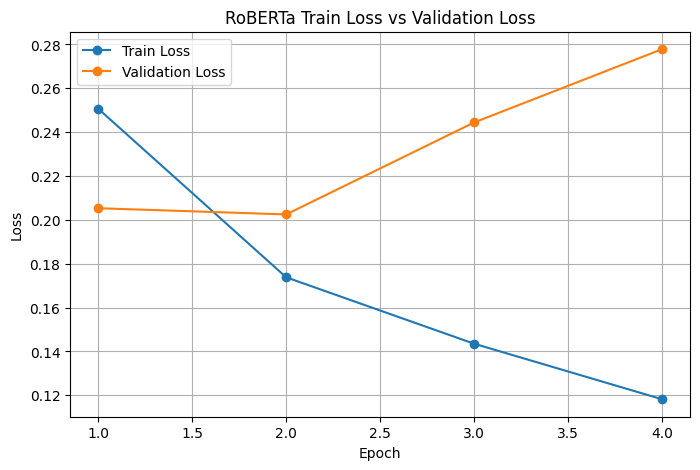

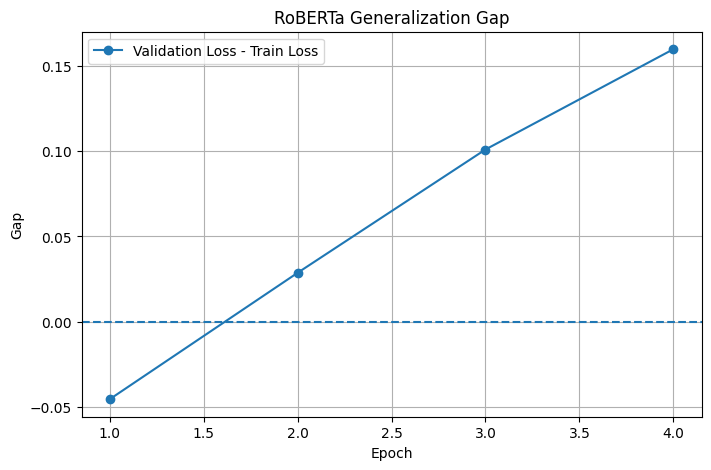

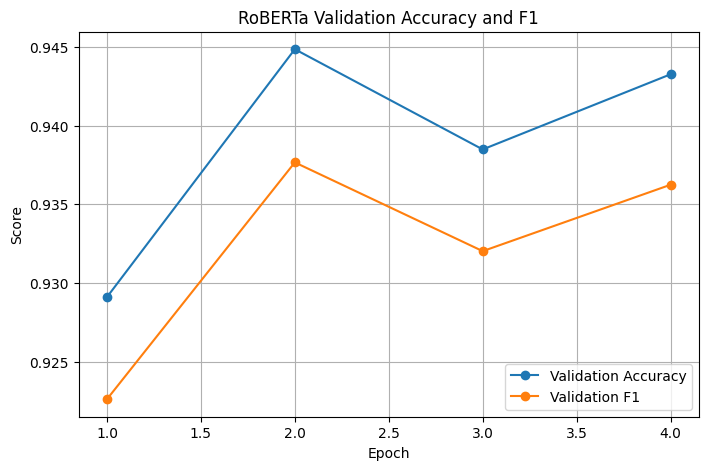


===== Best Model Info =====
Best checkpoint: /content/roberta_tuned_early_stopping/checkpoint-5974
Best eval_loss: 0.2024793177843094
Best epoch approximately: 2.0


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# ROBERTA OVERFITTING ANALYSIS
# =========================

history = roberta_tuned_trainer.state.log_history

train_losses = []
val_losses = []
val_accuracies = []
val_f1s = []
epochs = []

for log in history:
    if "loss" in log and "epoch" in log:
        train_losses.append(log["loss"])

    if "eval_loss" in log and "epoch" in log:
        val_losses.append(log["eval_loss"])
        val_accuracies.append(log["eval_accuracy"])
        val_f1s.append(log["eval_f1"])
        epochs.append(log["epoch"])

min_len = min(len(epochs), len(train_losses), len(val_losses))

epochs = epochs[:min_len]
train_losses = train_losses[:min_len]
val_losses = val_losses[:min_len]
val_accuracies = val_accuracies[:min_len]
val_f1s = val_f1s[:min_len]

gap = [
    val_losses[i] - train_losses[i]
    for i in range(min_len)
]

analysis_df = pd.DataFrame({
    "epoch": epochs,
    "train_loss": train_losses,
    "validation_loss": val_losses,
    "generalization_gap": gap,
    "validation_accuracy": val_accuracies,
    "validation_f1": val_f1s
})

print(analysis_df)

# =========================
# 1) TRAIN vs VALIDATION LOSS
# =========================

plt.figure(figsize=(8,5))
plt.plot(analysis_df["epoch"], analysis_df["train_loss"], marker="o", label="Train Loss")
plt.plot(analysis_df["epoch"], analysis_df["validation_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RoBERTa Train Loss vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("roberta_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 2) GENERALIZATION GAP
# =========================

plt.figure(figsize=(8,5))
plt.plot(analysis_df["epoch"], analysis_df["generalization_gap"], marker="o", label="Validation Loss - Train Loss")
plt.axhline(y=0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Gap")
plt.title("RoBERTa Generalization Gap")
plt.legend()
plt.grid(True)
plt.savefig("roberta_generalization_gap.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 3) VALIDATION ACCURACY / F1
# =========================

plt.figure(figsize=(8,5))
plt.plot(analysis_df["epoch"], analysis_df["validation_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(analysis_df["epoch"], analysis_df["validation_f1"], marker="o", label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("RoBERTa Validation Accuracy and F1")
plt.legend()
plt.grid(True)
plt.savefig("roberta_validation_scores.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 4) BEST EPOCH MARKER
# =========================

best_checkpoint = roberta_tuned_trainer.state.best_model_checkpoint
best_metric = roberta_tuned_trainer.state.best_metric

print("\n===== Best Model Info =====")
print("Best checkpoint:", best_checkpoint)
print("Best eval_loss:", best_metric)

steps_per_epoch = len(train_dataset) / roberta_tuned_trainer.args.per_device_train_batch_size

if best_checkpoint is not None:
    checkpoint_step = int(best_checkpoint.split("-")[-1])
    best_epoch = checkpoint_step / steps_per_epoch
    print("Best epoch approximately:", round(best_epoch, 2))

# 6. Unseen Test Evaluation

Evaluate the selected RoBERTa model on data held out from model development.

In [31]:
import pandas as pd

unseen_df = pd.read_csv("/content/unseen_dataset.csv")

print(unseen_df.shape)
unseen_df.head()

(3144, 2)


,text,label
0,Today's youth is being blamed for distracted d...,0
1,Why don't YOU violate my menstruating vagina? ...,1
2,CM carry op,0
3,9,1
4,"""\n\n Nominated English football champions as ...",0


In [32]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# =========================
# PREDICT ON UNSEEN
# =========================

texts = unseen_df["text"].astype(str).tolist()
y_true = unseen_df["label"].values

all_probs = []

roberta_tuned_trainer.model.eval()

for text in texts:

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        k: v.to(roberta_tuned_trainer.model.device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = roberta_tuned_trainer.model(**inputs)

    probs = torch.softmax(
        outputs.logits,
        dim=1
    )

    toxic_prob = probs[0][1].item()

    all_probs.append(toxic_prob)

all_probs = np.array(all_probs)

y_pred = (all_probs >= 0.5).astype(int)

# =========================
# RESULTS
# =========================

print("===== UNSEEN TEST =====")

print(
    "Accuracy :",
    accuracy_score(y_true, y_pred)
)

print(
    "Precision:",
    precision_score(y_true, y_pred)
)

print(
    "Recall   :",
    recall_score(y_true, y_pred)
)

print(
    "F1 Score :",
    f1_score(y_true, y_pred)
)

print("\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

===== UNSEEN TEST =====
Accuracy : 0.9376590330788804
Precision: 0.9467455621301775
Recall   : 0.9116809116809117
F1 Score : 0.9288824383164006


              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1740
           1       0.95      0.91      0.93      1404

    accuracy                           0.94      3144
   macro avg       0.94      0.94      0.94      3144
weighted avg       0.94      0.94      0.94      3144



# 7. Gradio Demo

Launch a simple interactive toxicity-classification interface.

In [ ]:
!pip install gradio -q

import gradio as gr
import torch

# =========================
# PREDICTION FUNCTION
# =========================


def predict_toxic(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        k: v.to(roberta_tuned_trainer.model.device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = roberta_tuned_trainer.model(**inputs)

    probs = torch.softmax(
        outputs.logits,
        dim=1
    )

    non_toxic_prob = probs[0][0].item()
    toxic_prob = probs[0][1].item()

    prediction = (
        "TOXIC 🔴"
        if toxic_prob >= 0.5
        else "NON-TOXIC 🟢"
    )

    return (
        prediction,
        f"{toxic_prob:.4f}",
        f"{non_toxic_prob:.4f}"
    )

# =========================
# GRADIO UI
# =========================

demo = gr.Interface(
    fn=predict_toxic,

    inputs=gr.Textbox(
        lines=4,
        label="Enter a game chat message"
    ),

    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Toxic Probability"),
        gr.Textbox(label="Non-Toxic Probability")
    ],

    title="🎮 Gaming Toxicity Detection",
    description="RoBERTa Tuned + Early Stopping"
)

demo.launch(share=True)

## Model export

The trained model can be saved locally with `save_pretrained(...)`. Large model artifacts are intentionally not included in this repository.
